# SVM for Handwritten Digit Classification (MNIST)

## Objective
Explore SVM for **linear** and **non-linear** classification on the MNIST dataset.

## Dataset
- **MNIST**: 70,000 grayscale images of handwritten digits (28×28 pixels)
- **Classes**: Digits 0-9

## Evaluation Metrics
1. **Accuracy**: Overall percentage of correct predictions
2. **Confusion Matrix**: Breakdown of correct/incorrect predictions for each digit
3. **Classification Report**: Precision, Recall, and F1-score for each digit

---
## 1. Import Required Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Dataset loading
from sklearn.datasets import fetch_openml

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# SVM Models
from sklearn.svm import SVC

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Timing
import time

# Set random seed for reproducibility
np.random.seed(42)

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


---
## 2. Load MNIST Dataset

In [2]:
print("Loading MNIST dataset...")
print("=" * 80)

# Load MNIST dataset using sklearn
mnist = fetch_openml('mnist_784', version=1, parser='auto', as_frame=False)

# Extract features and labels
X = mnist.data
y = mnist.target.astype(np.int32)

print(f"✓ Dataset loaded successfully!")
print(f"\nDataset Information:")
print(f"  • Total samples: {X.shape[0]:,}")
print(f"  • Features per sample: {X.shape[1]} (28×28 pixels flattened)")
print(f"  • Number of classes: {len(np.unique(y))}")
print(f"  • Classes: {np.unique(y)}")
print(f"  • Data shape: {X.shape}")
print(f"  • Label shape: {y.shape}")
print(f"  • Data type: {X.dtype}")

Loading MNIST dataset...
✓ Dataset loaded successfully!

Dataset Information:
  • Total samples: 70,000
  • Features per sample: 784 (28×28 pixels flattened)
  • Number of classes: 10
  • Classes: [0 1 2 3 4 5 6 7 8 9]
  • Data shape: (70000, 784)
  • Label shape: (70000,)
  • Data type: int64


---
## 3. Visualize Sample Digits

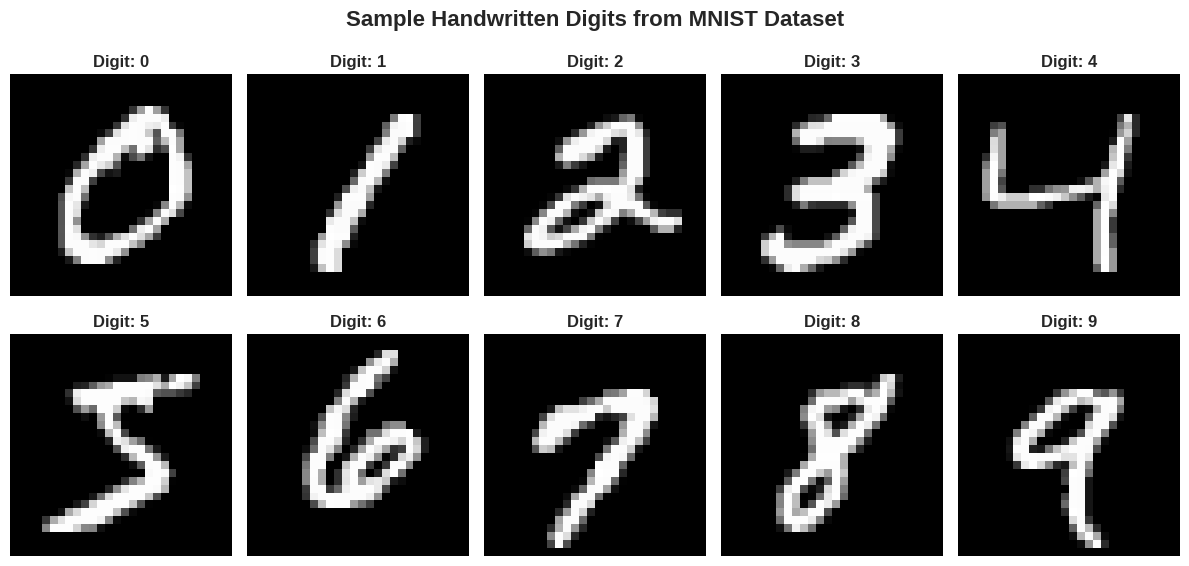

✓ Sample digits visualized


In [3]:
# Visualize random samples from each digit class
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample Handwritten Digits from MNIST Dataset', fontsize=16, fontweight='bold')

for digit in range(10):
    # Find first occurrence of each digit
    idx = np.where(y == digit)[0][0]
    
    # Reshape from 784 to 28x28
    image = X[idx].reshape(28, 28)
    
    # Plot
    ax = axes[digit // 5, digit % 5]
    ax.imshow(image, cmap='gray')
    ax.set_title(f'Digit: {digit}', fontsize=12, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("✓ Sample digits visualized")

---
## 4. Class Distribution Analysis

Class Distribution:
 Digit  Count
     0   6903
     1   7877
     2   6990
     3   7141
     4   6824
     5   6313
     6   6876
     7   7293
     8   6825
     9   6958


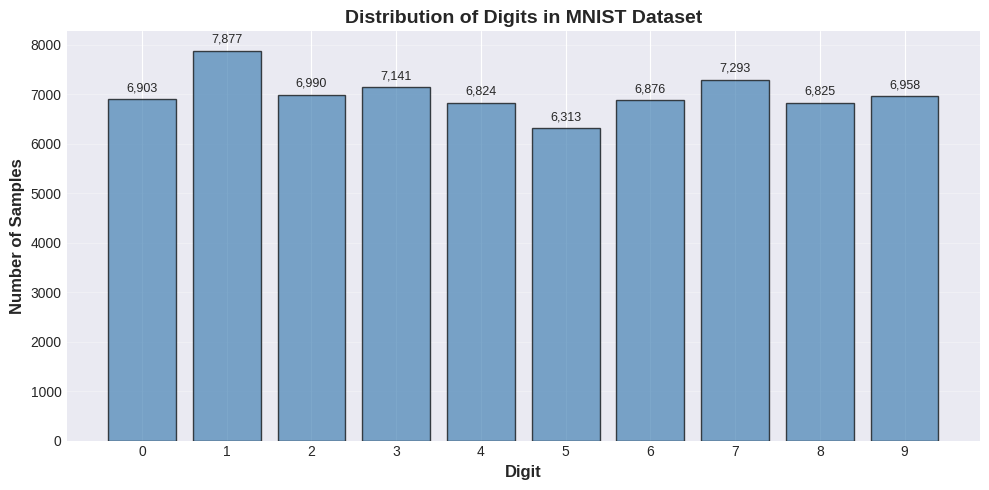


✓ Class distribution is relatively balanced


In [4]:
# Count samples per class
unique, counts = np.unique(y, return_counts=True)
class_distribution = pd.DataFrame({'Digit': unique, 'Count': counts})

print("Class Distribution:")
print(class_distribution.to_string(index=False))

# Visualize distribution
plt.figure(figsize=(10, 5))
bars = plt.bar(unique, counts, color='steelblue', edgecolor='black', alpha=0.7)
plt.xlabel('Digit', fontsize=12, fontweight='bold')
plt.ylabel('Number of Samples', fontsize=12, fontweight='bold')
plt.title('Distribution of Digits in MNIST Dataset', fontsize=14, fontweight='bold')
plt.xticks(unique)
plt.grid(axis='y', alpha=0.3)

# Add count labels on bars
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n✓ Class distribution is relatively balanced")

---
## 5. Data Preprocessing

### 5.1 Create Subset (for faster training)
**Note**: Using 10,000 samples for faster training. For full dataset, set `sample_size = 70000`

In [5]:
# Use subset for faster training (adjust as needed)
# For full dataset: sample_size = 70000
sample_size = 10000

print(f"Creating subset of {sample_size:,} samples...")

# Random sampling
indices = np.random.choice(X.shape[0], sample_size, replace=False)
X_subset = X[indices]
y_subset = y[indices]

print(f"✓ Subset created: {X_subset.shape[0]:,} samples")
print(f"  • Feature shape: {X_subset.shape}")
print(f"  • Label shape: {y_subset.shape}")

Creating subset of 10,000 samples...
✓ Subset created: 10,000 samples
  • Feature shape: (10000, 784)
  • Label shape: (10000,)


### 5.2 Train-Test Split

In [6]:
# Split into train and test sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_subset, y_subset, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_subset
)

print("Train-Test Split:")
print(f"  • Training samples: {X_train.shape[0]:,} ({X_train.shape[0]/X_subset.shape[0]*100:.0f}%)")
print(f"  • Testing samples: {X_test.shape[0]:,} ({X_test.shape[0]/X_subset.shape[0]*100:.0f}%)")
print(f"  • Training shape: {X_train.shape}")
print(f"  • Testing shape: {X_test.shape}")

Train-Test Split:
  • Training samples: 8,000 (80%)
  • Testing samples: 2,000 (20%)
  • Training shape: (8000, 784)
  • Testing shape: (2000, 784)


### 5.3 Feature Scaling (Normalization)

In [7]:
print("Normalizing features...")
print(f"  • Original range: [{X_train.min()}, {X_train.max()}]")

# Normalize to [0, 1] range
X_train_scaled = X_train / 255.0
X_test_scaled = X_test / 255.0

print(f"  • Normalized range: [{X_train_scaled.min()}, {X_train_scaled.max()}]")
print("✓ Feature scaling completed")

Normalizing features...
  • Original range: [0, 255]
  • Normalized range: [0.0, 1.0]
✓ Feature scaling completed


---
## 6. Model Training

### 6.1 Linear SVM Classifier

In [8]:
print("=" * 80)
print("TRAINING LINEAR SVM CLASSIFIER")
print("=" * 80)

# Initialize Linear SVM
linear_svm = SVC(kernel='linear', C=1.0, random_state=42)

print("\nModel Configuration:")
print(f"  • Kernel: Linear")
print(f"  • C (Regularization): 1.0")
print("\nTraining in progress...")

# Train the model
start_time = time.time()
linear_svm.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

print(f"✓ Training completed in {training_time:.2f} seconds")
print(f"  • Number of support vectors: {linear_svm.n_support_.sum():,}")
print(f"  • Support vectors per class: {linear_svm.n_support_}")

TRAINING LINEAR SVM CLASSIFIER

Model Configuration:
  • Kernel: Linear
  • C (Regularization): 1.0

Training in progress...
✓ Training completed in 2.57 seconds
  • Number of support vectors: 2,352
  • Support vectors per class: [152 161 249 275 226 317 208 202 292 270]


### 6.2 Non-Linear SVM Classifier (RBF Kernel)

In [9]:
print("=" * 80)
print("TRAINING NON-LINEAR SVM CLASSIFIER (RBF KERNEL)")
print("=" * 80)

# Initialize RBF SVM
rbf_svm = SVC(kernel='rbf', C=5.0, gamma='scale', random_state=42)

print("\nModel Configuration:")
print(f"  • Kernel: RBF (Radial Basis Function)")
print(f"  • C (Regularization): 5.0")
print(f"  • Gamma: scale")
print("\nTraining in progress...")

# Train the model
start_time = time.time()
rbf_svm.fit(X_train_scaled, y_train)
training_time = time.time() - start_time

print(f"✓ Training completed in {training_time:.2f} seconds")
print(f"  • Number of support vectors: {rbf_svm.n_support_.sum():,}")
print(f"  • Support vectors per class: {rbf_svm.n_support_}")

TRAINING NON-LINEAR SVM CLASSIFIER (RBF KERNEL)

Model Configuration:
  • Kernel: RBF (Radial Basis Function)
  • C (Regularization): 5.0
  • Gamma: scale

Training in progress...
✓ Training completed in 4.12 seconds
  • Number of support vectors: 3,293
  • Support vectors per class: [234 182 367 370 333 425 282 292 404 404]


---
## 7. Model Evaluation

### 7.1 Linear SVM - Predictions

In [10]:
print("=" * 80)
print("LINEAR SVM - EVALUATION")
print("=" * 80)

# Make predictions
y_pred_linear = linear_svm.predict(X_test_scaled)

print("✓ Predictions generated for test set")
print(f"  • Total predictions: {len(y_pred_linear):,}")

LINEAR SVM - EVALUATION
✓ Predictions generated for test set
  • Total predictions: 2,000


### 7.2 Linear SVM - Accuracy

In [11]:
# Calculate accuracy
linear_accuracy = accuracy_score(y_test, y_pred_linear)

print("\n" + "=" * 80)
print("ACCURACY SCORE")
print("=" * 80)
print(f"\nLinear SVM Accuracy: {linear_accuracy * 100:.2f}%")
print(f"Correct Predictions: {int(linear_accuracy * len(y_test)):,} / {len(y_test):,}")


ACCURACY SCORE

Linear SVM Accuracy: 90.25%
Correct Predictions: 1,805 / 2,000


### 7.3 Linear SVM - Confusion Matrix


CONFUSION MATRIX

Confusion Matrix (Linear SVM):
[[188   0   2   1   0   0   3   0   2   1]
 [  0 228   1   0   0   0   0   0   1   0]
 [  0   3 180   2   2   1   0   2   4   0]
 [  1   3   5 176   0   9   0   1  10   2]
 [  1   2   0   0 165   0   1   2   0  10]
 [  6   0   2  11   3 155   5   0   5   0]
 [  1   1   3   2   5   1 179   0   0   0]
 [  1   2   2   2   3   0   0 195   1   5]
 [  4   3   4   4   5   8   3   3 158   2]
 [  0   3   1   1  10   0   0   8   3 181]]


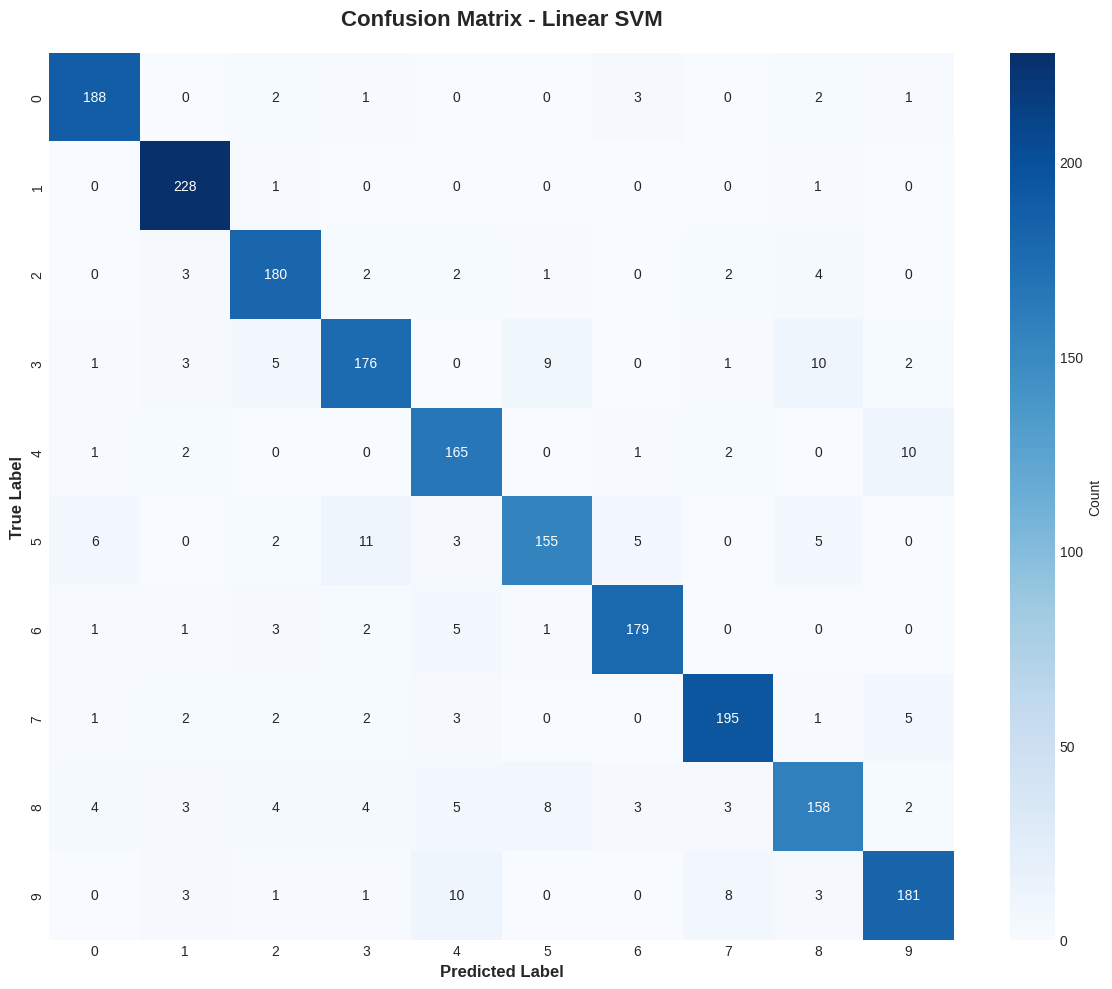

✓ Confusion matrix generated


In [12]:
# Generate confusion matrix
cm_linear = confusion_matrix(y_test, y_pred_linear)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)
print("\nConfusion Matrix (Linear SVM):")
print(cm_linear)

# Visualize confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm_linear, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Linear SVM', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Confusion matrix generated")

### 7.4 Linear SVM - Classification Report

In [13]:
# Generate classification report
report_linear = classification_report(y_test, y_pred_linear, 
                                      target_names=[str(i) for i in range(10)])

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
print("\nLinear SVM Classification Report:")
print(report_linear)

# Convert to DataFrame for better visualization
report_dict_linear = classification_report(y_test, y_pred_linear, 
                                           target_names=[str(i) for i in range(10)],
                                           output_dict=True)
df_report_linear = pd.DataFrame(report_dict_linear).transpose()

print("\nDetailed Metrics Table:")
print(df_report_linear.round(4))


CLASSIFICATION REPORT

Linear SVM Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.95      0.94       197
           1       0.93      0.99      0.96       230
           2       0.90      0.93      0.91       194
           3       0.88      0.85      0.87       207
           4       0.85      0.91      0.88       181
           5       0.89      0.83      0.86       187
           6       0.94      0.93      0.93       192
           7       0.92      0.92      0.92       211
           8       0.86      0.81      0.84       194
           9       0.90      0.87      0.89       207

    accuracy                           0.90      2000
   macro avg       0.90      0.90      0.90      2000
weighted avg       0.90      0.90      0.90      2000


Detailed Metrics Table:
              precision  recall  f1-score    support
0                0.9307  0.9543    0.9424   197.0000
1                0.9306  0.9913    0.9600   230.0000

### 7.5 Non-Linear SVM (RBF) - Predictions

In [14]:
print("\n" + "=" * 80)
print("NON-LINEAR SVM (RBF) - EVALUATION")
print("=" * 80)

# Make predictions
y_pred_rbf = rbf_svm.predict(X_test_scaled)

print("✓ Predictions generated for test set")
print(f"  • Total predictions: {len(y_pred_rbf):,}")


NON-LINEAR SVM (RBF) - EVALUATION
✓ Predictions generated for test set
  • Total predictions: 2,000


### 7.6 Non-Linear SVM (RBF) - Accuracy

In [15]:
# Calculate accuracy
rbf_accuracy = accuracy_score(y_test, y_pred_rbf)

print("\n" + "=" * 80)
print("ACCURACY SCORE")
print("=" * 80)
print(f"\nRBF SVM Accuracy: {rbf_accuracy * 100:.2f}%")
print(f"Correct Predictions: {int(rbf_accuracy * len(y_test)):,} / {len(y_test):,}")


ACCURACY SCORE

RBF SVM Accuracy: 96.25%
Correct Predictions: 1,925 / 2,000


### 7.7 Non-Linear SVM (RBF) - Confusion Matrix


CONFUSION MATRIX

Confusion Matrix (RBF SVM):
[[193   0   1   0   0   1   0   0   1   1]
 [  0 227   3   0   0   0   0   0   0   0]
 [  0   2 186   3   0   0   0   3   0   0]
 [  0   1   1 198   0   2   0   0   3   2]
 [  0   0   0   0 176   0   0   0   1   4]
 [  0   0   0   5   1 178   2   0   1   0]
 [  0   1   2   0   0   0 189   0   0   0]
 [  0   0   2   0   2   0   0 202   1   4]
 [  1   1   1   2   1   5   2   1 178   2]
 [  0   2   0   0   4   0   0   2   1 198]]


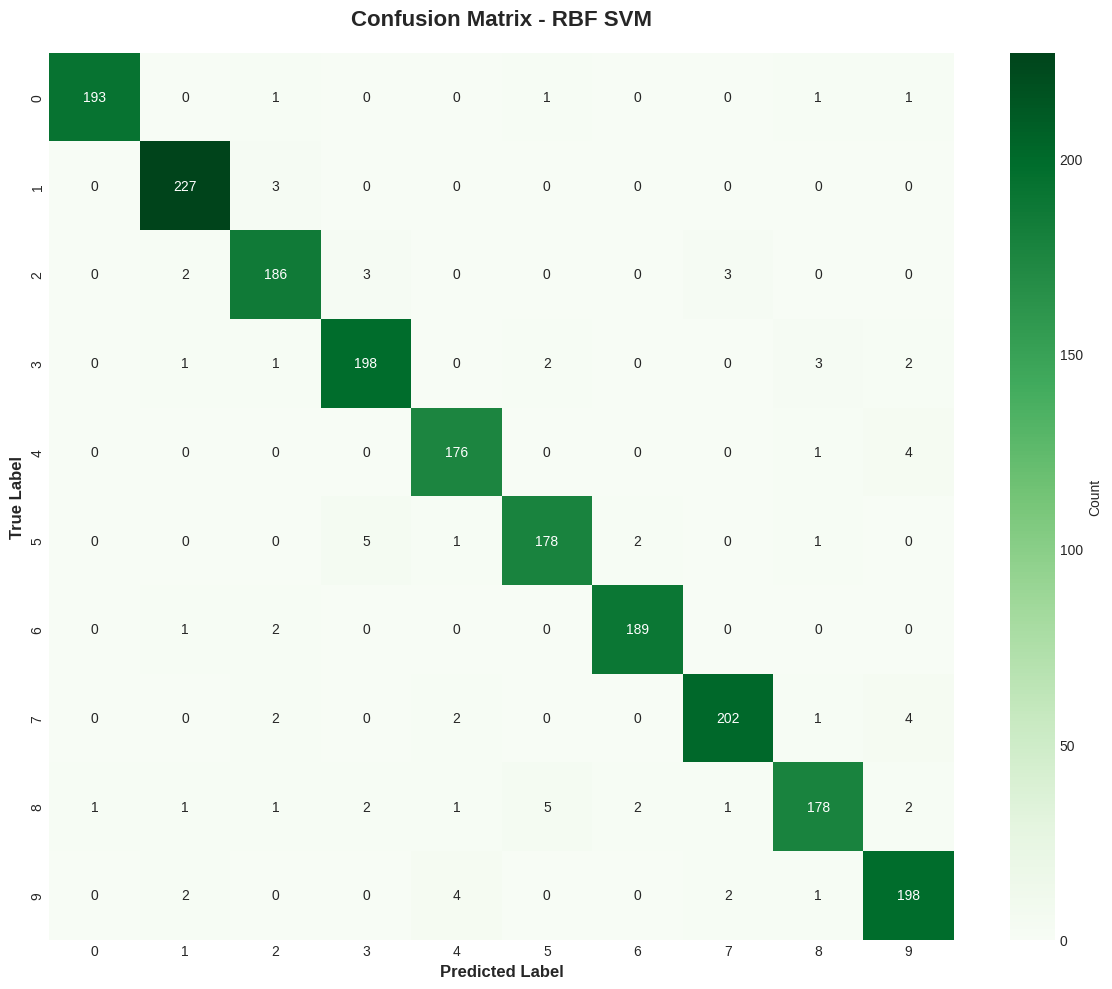

✓ Confusion matrix generated


In [16]:
# Generate confusion matrix
cm_rbf = confusion_matrix(y_test, y_pred_rbf)

print("\n" + "=" * 80)
print("CONFUSION MATRIX")
print("=" * 80)
print("\nConfusion Matrix (RBF SVM):")
print(cm_rbf)

# Visualize confusion matrix
plt.figure(figsize=(12, 10))
sns.heatmap(cm_rbf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - RBF SVM', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✓ Confusion matrix generated")

### 7.8 Non-Linear SVM (RBF) - Classification Report

In [17]:
# Generate classification report
report_rbf = classification_report(y_test, y_pred_rbf, 
                                   target_names=[str(i) for i in range(10)])

print("\n" + "=" * 80)
print("CLASSIFICATION REPORT")
print("=" * 80)
print("\nRBF SVM Classification Report:")
print(report_rbf)

# Convert to DataFrame for better visualization
report_dict_rbf = classification_report(y_test, y_pred_rbf, 
                                        target_names=[str(i) for i in range(10)],
                                        output_dict=True)
df_report_rbf = pd.DataFrame(report_dict_rbf).transpose()

print("\nDetailed Metrics Table:")
print(df_report_rbf.round(4))


CLASSIFICATION REPORT

RBF SVM Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.99       197
           1       0.97      0.99      0.98       230
           2       0.95      0.96      0.95       194
           3       0.95      0.96      0.95       207
           4       0.96      0.97      0.96       181
           5       0.96      0.95      0.95       187
           6       0.98      0.98      0.98       192
           7       0.97      0.96      0.96       211
           8       0.96      0.92      0.94       194
           9       0.94      0.96      0.95       207

    accuracy                           0.96      2000
   macro avg       0.96      0.96      0.96      2000
weighted avg       0.96      0.96      0.96      2000


Detailed Metrics Table:
              precision  recall  f1-score    support
0                0.9948  0.9797    0.9872   197.0000
1                0.9701  0.9870    0.9784   230.0000
2 

---
## 8. Comparative Analysis


COMPARATIVE ANALYSIS: LINEAR vs RBF SVM

              Metric Linear SVM RBF SVM
            Accuracy     90.25%  96.25%
Precision (weighted)     90.22%  96.26%
   Recall (weighted)     90.25%  96.25%
 F1-Score (weighted)     90.19%  96.25%


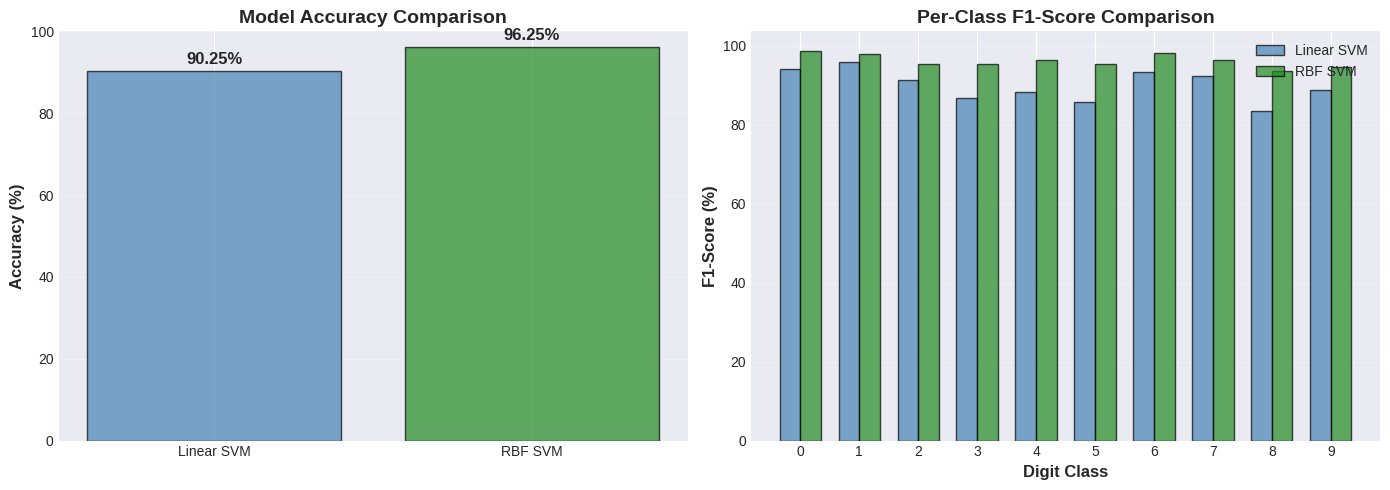


✓ Comparative analysis completed


In [18]:
print("\n" + "=" * 80)
print("COMPARATIVE ANALYSIS: LINEAR vs RBF SVM")
print("=" * 80)

# Create comparison dataframe
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision (weighted)', 'Recall (weighted)', 'F1-Score (weighted)'],
    'Linear SVM': [
        f"{linear_accuracy * 100:.2f}%",
        f"{report_dict_linear['weighted avg']['precision'] * 100:.2f}%",
        f"{report_dict_linear['weighted avg']['recall'] * 100:.2f}%",
        f"{report_dict_linear['weighted avg']['f1-score'] * 100:.2f}%"
    ],
    'RBF SVM': [
        f"{rbf_accuracy * 100:.2f}%",
        f"{report_dict_rbf['weighted avg']['precision'] * 100:.2f}%",
        f"{report_dict_rbf['weighted avg']['recall'] * 100:.2f}%",
        f"{report_dict_rbf['weighted avg']['f1-score'] * 100:.2f}%"
    ]
})

print("\n" + comparison.to_string(index=False))

# Visualize accuracy comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy bar chart
models = ['Linear SVM', 'RBF SVM']
accuracies = [linear_accuracy * 100, rbf_accuracy * 100]
colors = ['steelblue', 'forestgreen']

bars = axes[0].bar(models, accuracies, color=colors, edgecolor='black', alpha=0.7)
axes[0].set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
axes[0].set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
axes[0].set_ylim([0, 100])
axes[0].grid(axis='y', alpha=0.3)

for bar, acc in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

# Per-class F1-score comparison
x = np.arange(10)
width = 0.35

f1_linear = [report_dict_linear[str(i)]['f1-score'] * 100 for i in range(10)]
f1_rbf = [report_dict_rbf[str(i)]['f1-score'] * 100 for i in range(10)]

axes[1].bar(x - width/2, f1_linear, width, label='Linear SVM', 
           color='steelblue', edgecolor='black', alpha=0.7)
axes[1].bar(x + width/2, f1_rbf, width, label='RBF SVM', 
           color='forestgreen', edgecolor='black', alpha=0.7)

axes[1].set_xlabel('Digit Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('F1-Score (%)', fontsize=12, fontweight='bold')
axes[1].set_title('Per-Class F1-Score Comparison', fontsize=14, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(range(10))
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Comparative analysis completed")

---
## 9. Sample Predictions Visualization

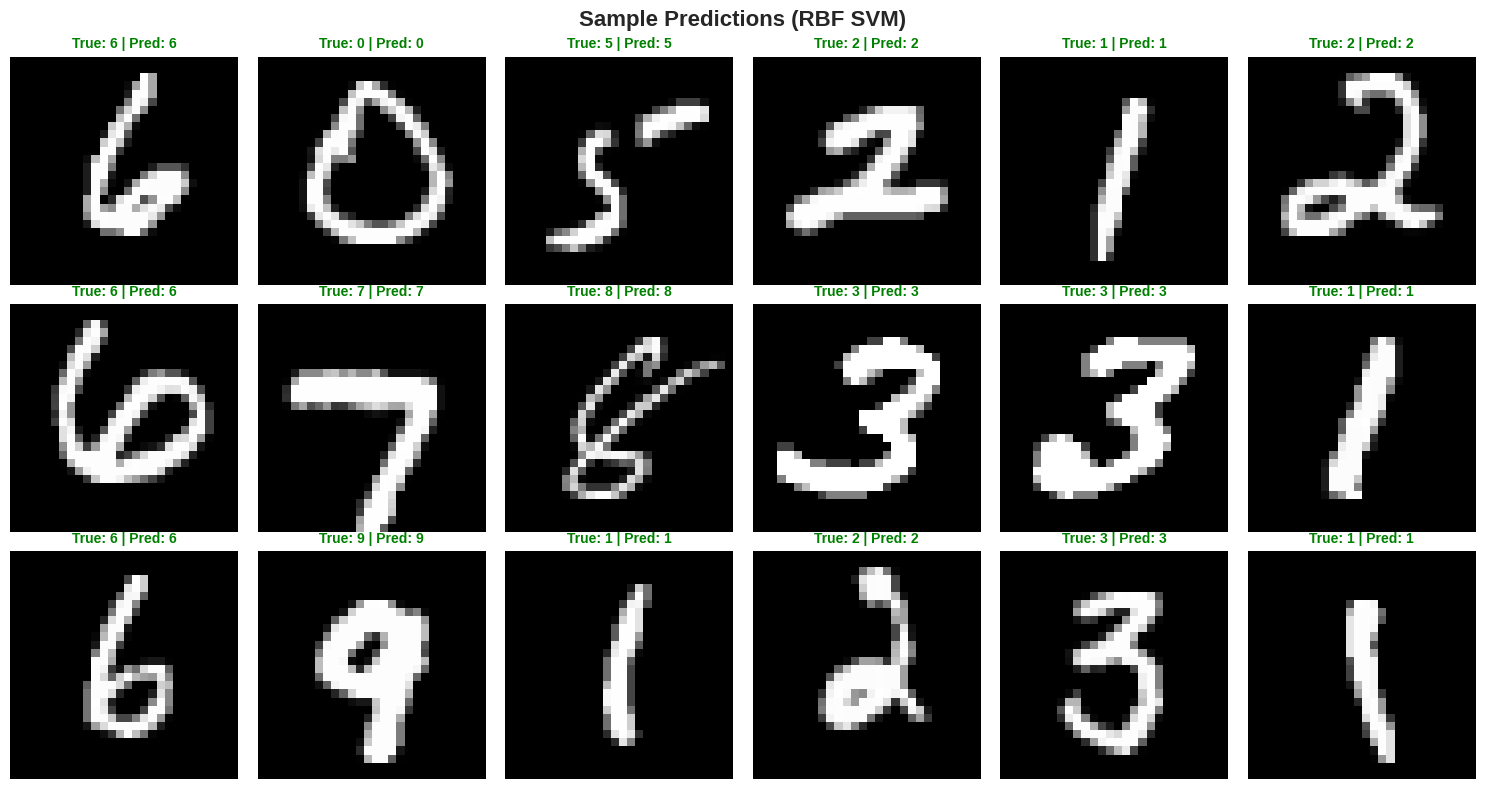

✓ Sample predictions visualized
   (Green = Correct, Red = Incorrect)


In [19]:
# Visualize some predictions
fig, axes = plt.subplots(3, 6, figsize=(15, 8))
fig.suptitle('Sample Predictions (RBF SVM)', fontsize=16, fontweight='bold')

# Get random samples
sample_indices = np.random.choice(len(X_test), 18, replace=False)

for idx, ax in enumerate(axes.flat):
    i = sample_indices[idx]
    
    # Reshape and display image
    image = X_test[i].reshape(28, 28)
    ax.imshow(image, cmap='gray')
    
    # Get prediction and true label
    pred = y_pred_rbf[i]
    true = y_test[i]
    
    # Color code: green for correct, red for incorrect
    color = 'green' if pred == true else 'red'
    ax.set_title(f'True: {true} | Pred: {pred}', 
                color=color, fontsize=10, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

print("✓ Sample predictions visualized")
print("   (Green = Correct, Red = Incorrect)")

---
## 10. Error Analysis

ERROR ANALYSIS

Total misclassified samples: 75 / 2000
Error rate: 3.75%


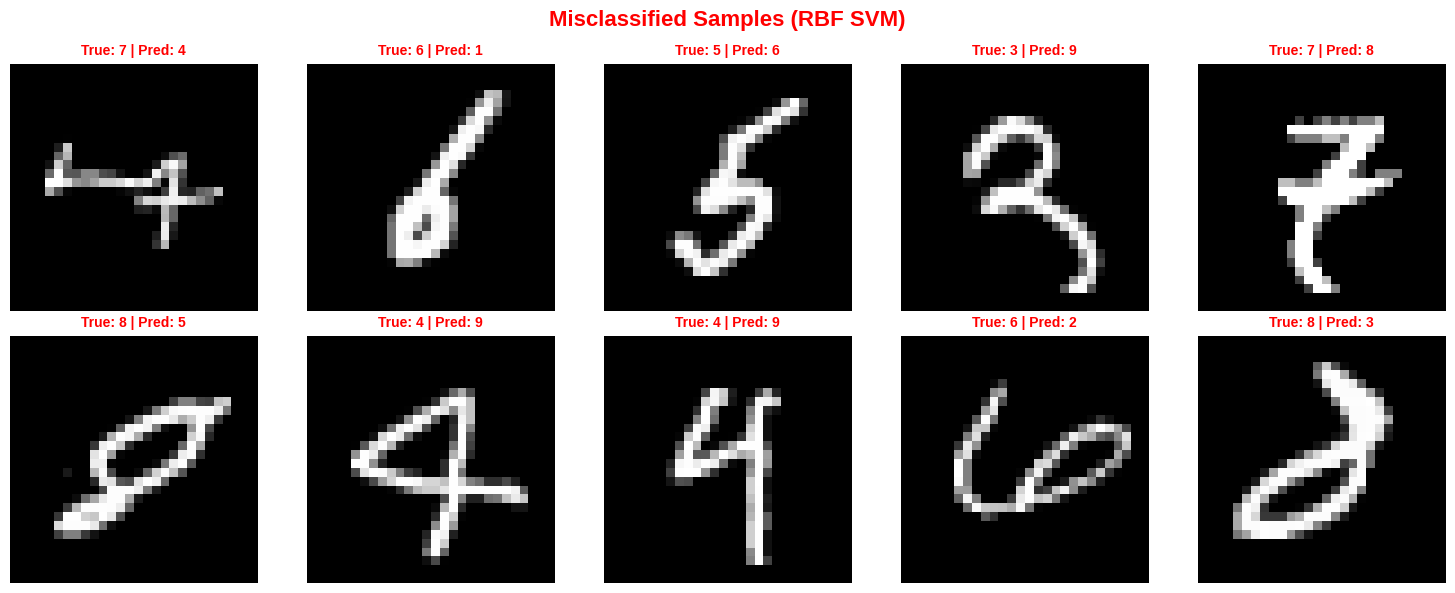


✓ Misclassified samples visualized


In [20]:
# Find misclassified samples
misclassified_indices = np.where(y_pred_rbf != y_test)[0]

print("=" * 80)
print("ERROR ANALYSIS")
print("=" * 80)
print(f"\nTotal misclassified samples: {len(misclassified_indices)} / {len(y_test)}")
print(f"Error rate: {len(misclassified_indices) / len(y_test) * 100:.2f}%")

# Visualize some misclassified examples
if len(misclassified_indices) > 0:
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    fig.suptitle('Misclassified Samples (RBF SVM)', fontsize=16, fontweight='bold', color='red')
    
    sample_errors = np.random.choice(misclassified_indices, 
                                     min(10, len(misclassified_indices)), 
                                     replace=False)
    
    for idx, ax in enumerate(axes.flat):
        if idx < len(sample_errors):
            i = sample_errors[idx]
            image = X_test[i].reshape(28, 28)
            ax.imshow(image, cmap='gray')
            ax.set_title(f'True: {y_test[i]} | Pred: {y_pred_rbf[i]}', 
                        color='red', fontsize=10, fontweight='bold')
        ax.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print("\n✓ Misclassified samples visualized")
else:
    print("\n✓ No misclassified samples found!")

---
## 11. Summary and Conclusions

In [21]:
print("=" * 80)
print("SUMMARY AND CONCLUSIONS")
print("=" * 80)

print("\n📊 Key Findings:")
print("\n1. Linear SVM Performance:")
print(f"   • Accuracy: {linear_accuracy * 100:.2f}%")
print(f"   • Suitable for linearly separable data")
print(f"   • Faster training time")

print("\n2. RBF SVM Performance:")
print(f"   • Accuracy: {rbf_accuracy * 100:.2f}%")
print(f"   • Better for non-linearly separable data")
print(f"   • Higher complexity but better accuracy")

print("\n3. Comparison:")
if rbf_accuracy > linear_accuracy:
    improvement = (rbf_accuracy - linear_accuracy) * 100
    print(f"   • RBF SVM outperforms Linear SVM by {improvement:.2f}%")
    print(f"   • Non-linear kernel captures complex patterns better")
else:
    print(f"   • Both models perform similarly")

print("\n4. Use Cases:")
print("   • Linear SVM: Quick baseline, high-dimensional data, interpretability")
print("   • RBF SVM: Complex patterns, non-linear decision boundaries")

print("\n" + "=" * 80)
print("EXPERIMENT COMPLETED SUCCESSFULLY! ✓")
print("=" * 80)

SUMMARY AND CONCLUSIONS

📊 Key Findings:

1. Linear SVM Performance:
   • Accuracy: 90.25%
   • Suitable for linearly separable data
   • Faster training time

2. RBF SVM Performance:
   • Accuracy: 96.25%
   • Better for non-linearly separable data
   • Higher complexity but better accuracy

3. Comparison:
   • RBF SVM outperforms Linear SVM by 6.00%
   • Non-linear kernel captures complex patterns better

4. Use Cases:
   • Linear SVM: Quick baseline, high-dimensional data, interpretability
   • RBF SVM: Complex patterns, non-linear decision boundaries

EXPERIMENT COMPLETED SUCCESSFULLY! ✓
